# Regularização

### Exemplos com LR e SVM

In [1]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


Dividindo os dados em 70% treino e 30 teste:

In [2]:
from sklearn.cross_validation import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

/mnt/files/envs/tf/lib/python3.6/site-packages/sklearn/cross_validation.py:41: DeprecationWarning: This module was deprecated in version 0.18 in favor of the model_selection module into which all the refactored classes and functions are moved. Also note that the interface of the new CV iterators are different from that of this module. This module will be removed in 0.20.
  "This module will be removed in 0.20.", DeprecationWarning)


Transforma os dados para forma com média próxima de zero e um desvio padrão próximo a um:

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [4]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import warnings


def versiontuple(v):
    return tuple(map(int, (v.split("."))))


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # configura cores 
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'green', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plota as regiões de decisão
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)

    # destaca samples de teste
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(x=X_test[:, 0],
                    y=X_test[:, 1],
                    facecolors='none', 
                    edgecolors='black',
                    #c='black',
                    s=55, label='conjunto de teste')

**Regressão Logistica**

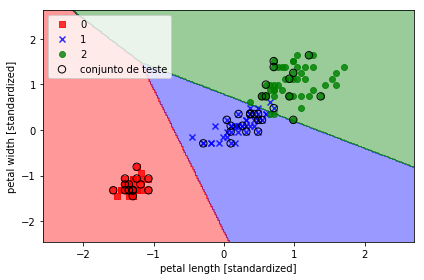

In [5]:
from sklearn.linear_model import LogisticRegression

X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))

lr = LogisticRegression(C=100.0, random_state=0)
lr.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined, classifier=lr, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import accuracy_score
y_pred = lr.predict(X_test_std)
print('Acurácia: %.2f' % accuracy_score(y_test, y_pred))

Acurácia: 0.98


In [7]:
# Obtendo as probabilidades
lr.predict_proba(X_test_std)[0,:]

array([2.80403686e-08, 6.50898052e-02, 9.34910167e-01])

In [8]:
# Verificando um ponto em específico --> primeiro elemento do teste
print(X_combined_std[105])
print(X_test_std[0])

[0.70793846 1.50872803]
[0.70793846 1.50872803]


**SVM linear**

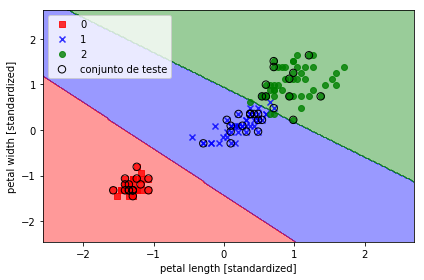

In [9]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1.0, random_state=0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined,
                      classifier=svm, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
y_pred = svm.predict(X_test_std)
print('Acurácia: %.2f' % accuracy_score(y_test, y_pred))

Acurácia: 0.98


**SVM não-linear**

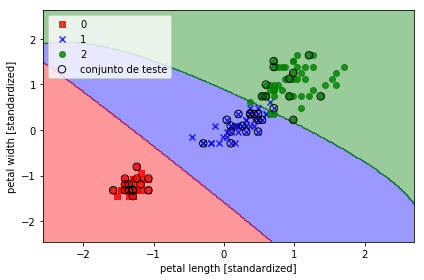

In [11]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=0, gamma=0.2, C=1.0)
svm.fit(X_train_std, y_train)

plot_decision_regions(X_combined_std, y_combined,
                      classifier=svm, test_idx=range(105,150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
y_pred = svm.predict(X_test_std)
print('Acurácia: %.2f' % accuracy_score(y_test, y_pred))

Acurácia: 0.98


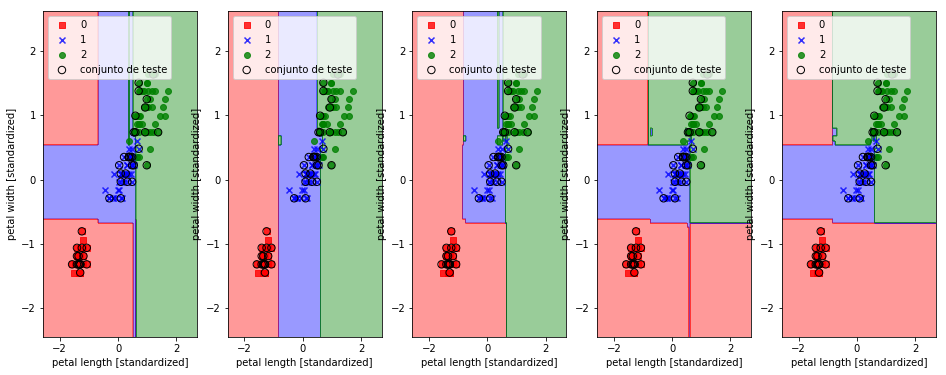

In [23]:
# definindo um gamma bem mais alto
from sklearn.ensemble import RandomForestClassifier

plt.figure(figsize=(16, 6))

for i, trees in enumerate((3, 10, 20, 50, 100)):
    svm = RandomForestClassifier(n_estimators=trees)
    svm.fit(X_train_std, y_train)

    plt.subplot(1, 5, i + 1)
    plot_decision_regions(X_combined_std, y_combined, 
                          classifier=svm, test_idx=range(105, 150))
    plt.xlabel('petal length [standardized]')
    plt.ylabel('petal width [standardized]')
    plt.legend(loc='upper left')

In [14]:
y_pred = svm.predict(X_test_std)
print('Acurácia: %.2f' % accuracy_score(y_test, y_pred))

Acurácia: 1.00
